In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def prepare_my_image(image_path):
    # 1. Load, grayscale, and resize
    img = tf.keras.utils.load_img(
        image_path,
        color_mode="grayscale",
        target_size=(28, 28)
    )
    img_array = tf.keras.utils.img_to_array(img)

    # 2. Invert the colors (White paper -> Black, Dark ink -> White)
    img_array = 255.0 - img_array

    # 3. Normalize to decimals (0.0 to 1.0)
    img_array = img_array / 255.0

    # --- 4. THE NEW FIX: THRESHOLDING ---
    # Any annoying gray background noise (below 0.5) gets crushed to pure black (0.0)
    img_array = np.where(img_array < 0.5, 0.0, img_array)

    # Any light gray ink gets boosted to pure bright white (1.0)
    img_array = np.where(img_array > 0.5, 1.0, img_array)

    # --- 5. VISUAL CHECK ---
    # Let's plot it right inside the function so you can immediately see if it worked
    plt.imshow(img_array[:, :, 0], cmap='gray')
    plt.title("Upgraded Thresholded Image")
    plt.colorbar()
    plt.show()

    # 6. Add the Batch dimension for the model
    final_input = tf.expand_dims(img_array, axis=0)

    return final_input

# Run it again!
# my_ready_image = prepare_my_image_v2("my_handwritten_digit.jpg")


In [2]:
model=tf.keras.models.load_model("my_mnist_model.keras")

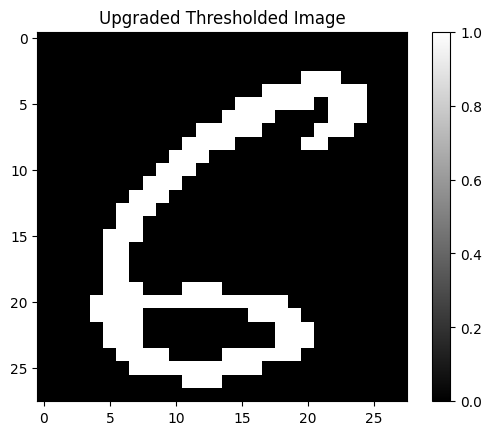

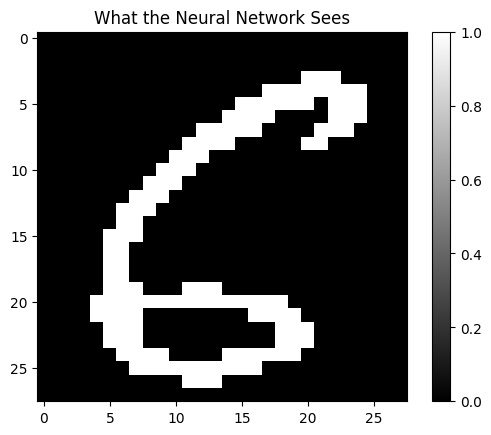

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
Raw Probabilities: [[1.3587573e-03 4.2762584e-04 4.1211686e-01 8.3755680e-05 1.7397781e-08
  5.8473688e-01 8.6864573e-04 2.1086370e-07 4.0718971e-04 3.1989408e-08]]
The model is 58.47% sure this is a 5!


In [3]:
import numpy as np

my_ready_image = prepare_my_image("digt.png")
# 1. Pass your prepared image into the model
# (Assuming 'my_ready_image' is the output from the function we just wrote)

import matplotlib.pyplot as plt

# (Assuming my_ready_image is the output of your preparation function)
# Let's pull the 28x28 grid back out of the batch
image_to_view = my_ready_image[0, :, :, 0]

# Display it exactly how the model sees it
plt.imshow(image_to_view, cmap='gray')
plt.title("What the Neural Network Sees")
plt.colorbar() # This shows you if the background is truly 0.0 (black)
plt.show()

raw_predictions = model.predict(my_ready_image)

# Optional: Print the raw math just to see what the neural network is "thinking"
print("Raw Probabilities:", raw_predictions)

# 2. Find the POSITION (index) of the highest probability
# Since index 0 represents the digit 0, index 1 is 1, etc.,
# the index perfectly matches our predicted digit!
predicted_digit = np.argmax(raw_predictions)

# 3. Grab the actual confidence score for that winning digit
confidence_decimal = np.max(raw_predictions)
confidence_percentage = confidence_decimal * 100

# 4. Print the final, human-readable result
print(f"The model is {confidence_percentage:.2f}% sure this is a {predicted_digit}!")